<a href="https://colab.research.google.com/github/mehrshad-sdtn/DeepLearning/blob/master/Playground/Deep_Convex_Estimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### A regression model to estimate a convex function using a multi-layer perceptron in PyTorch

In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [2]:
points = 500

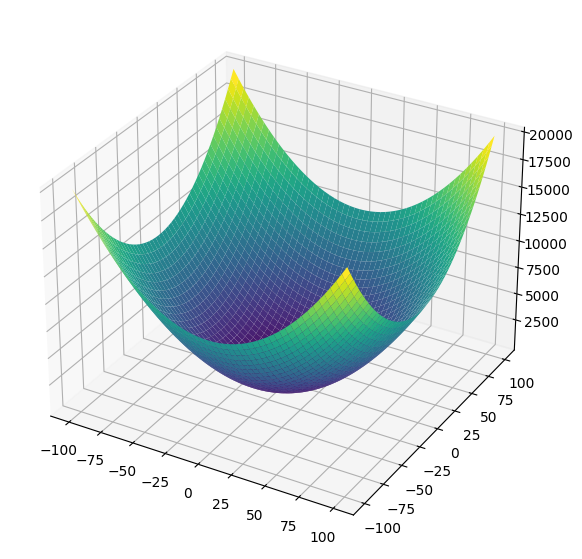

In [3]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x1, x2 = np.meshgrid(np.linspace(-100, 100, points), np.linspace(-100, 100, points))
# Convex
y = x1**2 + x2**2
ax.plot_surface(x1, x2, y, cmap='viridis')
plt.show()

In [4]:
x1_flat = x1.flatten()
x2_flat = x2.flatten()
inputs = np.vstack((x1_flat, x2_flat)).T

# Flatten the labels array
labels = y.flatten()

# Convert inputs and labels to PyTorch tensors
inputs_tensor = torch.tensor(inputs, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)
dataset = TensorDataset(inputs_tensor, labels_tensor)

batch_size = 128
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(inputs_tensor.shape, labels_tensor.shape)

torch.Size([250000, 2]) torch.Size([250000, 1])


In [5]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()
    self.fc1 = nn.Linear(2, 10)
    self.fc2 = nn.Linear(10, 1)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return x



In [6]:
model = NeuralNetwork()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

NeuralNetwork(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)

In [9]:
num_epochs = 100
learning_rate = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
losses = []
for epoch in range(num_epochs):
    print(f'Epoch {epoch + 1}/{num_epochs}')
    print('-' * 50)

    model.train()
    train_loss = 0.0
    num_batches = len(dataloader)
    for batch_idx, (data, targets) in enumerate(dataloader):
        if batch_idx % 50 == 0:
          print('=', end='')
        # 1) data and targets -> device
        data = data.to(device)
        targets = targets.to(device)

        # 2) optimizer init
        optimizer.zero_grad()

        # 3) forward prop
        outputs = model(data)
        loss = criterion(outputs, targets)

        # 4) backward prop
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / num_batches
    losses.append(avg_train_loss)
    print('\n')
    print(f'Train Loss: {avg_train_loss:.4f}')


Epoch 1/100
--------------------------------------------------

Train Loss: 26541079.6704
Epoch 2/100
--------------------------------------------------

Train Loss: 7395858.5624
Epoch 3/100
--------------------------------------------------

Train Loss: 3701628.4706
Epoch 4/100
--------------------------------------------------

Train Loss: 3096422.0311
Epoch 5/100
--------------------------------------------------

Train Loss: 2822366.5353
Epoch 6/100
--------------------------------------------------

Train Loss: 2704877.3770
Epoch 7/100
--------------------------------------------------

Train Loss: 2640549.1993
Epoch 8/100
--------------------------------------------------

Train Loss: 2590986.7165
Epoch 9/100
--------------------------------------------------

Train Loss: 2547619.5174
Epoch 10/100
--------------------------------------------------

Train Loss: 2504983.6372
Epoch 11/100
--------------------------------------------------

Train Loss: 2462447.3650
Epoch 12/100
-----

In [13]:
model.eval()
with torch.no_grad():
  preds = model(inputs_tensor.to(device))

In [15]:
inputs_numpy = inputs_tensor.numpy()
labels_numpy = preds.cpu().numpy().flatten()

x1_flat_reversed = inputs_numpy[:, 0]
x2_flat_reversed = inputs_numpy[:, 1]

# Reshape the flattened arrays back into the original meshgrid shape
x1_reversed = x1_flat_reversed.reshape((points, points))
x2_reversed = x2_flat_reversed.reshape((points, points))
y_reversed = labels_numpy.reshape((points, points))

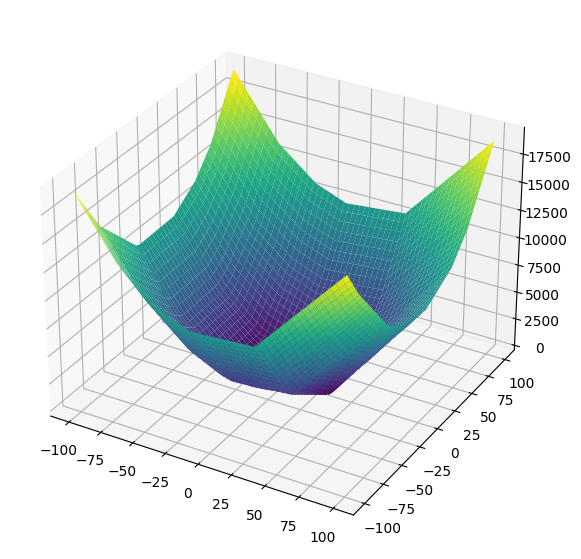

In [16]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x1_reversed, x2_reversed, y_reversed, cmap='viridis')
plt.show()

**Longer training will lead to better results**